# Capítulo 04. Ética, privacidad, sesgos y gobernanza de datos

Este cuaderno usa datos simulados de hogares ficticios para practicar una auditoría básica de cobertura y una matriz de riesgos. No contiene datos personales reales.

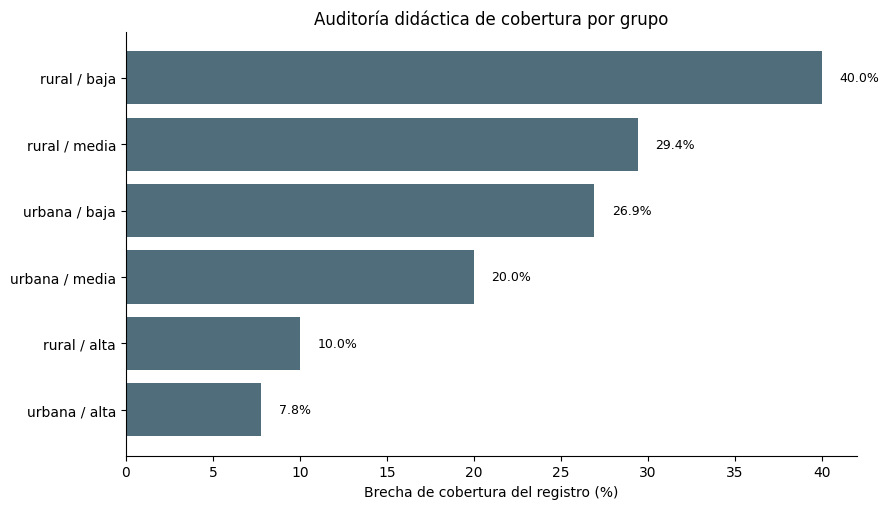

,zona,conectividad,hogares,cobertura_registro,tasa_priorizacion,exclusion_potencial,brecha_cobertura
0,rural,alta,10,0.900000,0.400000,0.000000,0.100000
1,rural,baja,40,0.600000,0.300000,0.275000,0.400000
2,rural,media,34,0.705882,0.323529,0.147059,0.294118
3,urbana,alta,90,0.922222,0.266667,0.011111,0.077778
4,urbana,baja,26,0.730769,0.500000,0.230769,0.269231
5,urbana,media,40,0.800000,0.200000,0.125000,0.200000


,riesgo,tipo,severidad,mitigacion
0,Subcobertura de hogares rurales o sin conectiv...,sesgo de cobertura,alta,"canales presenciales, búsqueda activa y valida..."
1,Uso de variables sensibles sin justificación,privacidad,alta,"minimización, base legal, control de acceso y ..."
2,Regla automática sin apelación,gobernanza,alta,"revisión humana, mecanismo de reclamo y trazab..."
3,Publicación de celdas pequeñas,confidencialidad,media,"agregación, supresión estadística y revisión a..."


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


BOOK_SLUG = "politicas_publicas_basadas_en_datos"


def find_book_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        direct = path
        nested = path / "books" / BOOK_SLUG
        if (direct / "chapters" / "01_decisiones_publicas_basadas_en_datos.md").exists():
            return direct
        if (nested / "chapters" / "01_decisiones_publicas_basadas_en_datos.md").exists():
            return nested
    raise FileNotFoundError("No se encontró la raíz del libro.")


book_root = find_book_root()
tables_dir = book_root / "outputs" / "tables"
figures_dir = book_root / "outputs" / "figures"
reports_dir = book_root / "outputs" / "reports"
for directory in [tables_dir, figures_dir, reports_dir]:
    directory.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260507)
n = 240
zona = rng.choice(["urbana", "rural"], size=n, p=[0.62, 0.38])
conectividad = np.where(
    zona == "urbana",
    rng.choice(["alta", "media", "baja"], size=n, p=[0.52, 0.34, 0.14]),
    rng.choice(["alta", "media", "baja"], size=n, p=[0.12, 0.36, 0.52]),
)
vulnerabilidad = rng.choice(["baja", "media", "alta"], size=n, p=[0.30, 0.42, 0.28])
prob_registro = np.where(zona == "urbana", 0.90, 0.74)
prob_registro = np.where(conectividad == "baja", prob_registro - 0.18, prob_registro)
prob_registro = np.clip(prob_registro, 0.35, 0.96)
en_registro = rng.binomial(1, prob_registro).astype(bool)

hogares = pd.DataFrame(
    {
        "hogar_ficticio": [f"H{i:03d}" for i in range(1, n + 1)],
        "zona": zona,
        "conectividad": conectividad,
        "vulnerabilidad": vulnerabilidad,
        "en_registro": en_registro,
    }
)
hogares["puntaje_necesidad"] = (
    hogares["vulnerabilidad"].map({"baja": 35, "media": 62, "alta": 88})
    + hogares["conectividad"].map({"alta": 0, "media": 6, "baja": 12})
    + rng.normal(0, 4, size=n)
).round(1)
hogares["priorizado_por_regla"] = hogares["en_registro"] & (hogares["puntaje_necesidad"] >= 70)
hogares["exclusion_potencial"] = (~hogares["en_registro"]) & (hogares["puntaje_necesidad"] >= 70)

auditoria = (
    hogares.groupby(["zona", "conectividad"], as_index=False)
    .agg(
        hogares=("hogar_ficticio", "count"),
        cobertura_registro=("en_registro", "mean"),
        tasa_priorizacion=("priorizado_por_regla", "mean"),
        exclusion_potencial=("exclusion_potencial", "mean"),
    )
)
auditoria["brecha_cobertura"] = 1 - auditoria["cobertura_registro"]

matriz_riesgos = pd.DataFrame(
    [
        {
            "riesgo": "Subcobertura de hogares rurales o sin conectividad",
            "tipo": "sesgo de cobertura",
            "severidad": "alta",
            "mitigacion": "canales presenciales, búsqueda activa y validación territorial",
        },
        {
            "riesgo": "Uso de variables sensibles sin justificación",
            "tipo": "privacidad",
            "severidad": "alta",
            "mitigacion": "minimización, base legal, control de acceso y registro de uso",
        },
        {
            "riesgo": "Regla automática sin apelación",
            "tipo": "gobernanza",
            "severidad": "alta",
            "mitigacion": "revisión humana, mecanismo de reclamo y trazabilidad de decisiones",
        },
        {
            "riesgo": "Publicación de celdas pequeñas",
            "tipo": "confidencialidad",
            "severidad": "media",
            "mitigacion": "agregación, supresión estadística y revisión antes de publicar",
        },
    ]
)

auditoria.to_csv(tables_dir / "chapter_04_auditoria_cobertura.csv", index=False)
matriz_riesgos.to_csv(tables_dir / "chapter_04_matriz_riesgos.csv", index=False)

plot_data = auditoria.sort_values("brecha_cobertura", ascending=True).copy()
plot_data["grupo"] = plot_data["zona"] + " / " + plot_data["conectividad"]
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(plot_data["grupo"], plot_data["brecha_cobertura"] * 100, color="#4f6d7a")
ax.set_xlabel("Brecha de cobertura del registro (%)")
ax.set_title("Auditoría didáctica de cobertura por grupo")
for index, value in enumerate(plot_data["brecha_cobertura"] * 100):
    ax.text(value + 1, index, f"{value:.1f}%", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(figures_dir / "chapter_04_brechas_cobertura.png", dpi=180)
plt.show()

nota = """# Nota metodológica - Capítulo 04

Los datos de este cuaderno son simulados y representan hogares ficticios. La auditoría muestra cómo documentar brechas de cobertura, exclusión potencial y riesgos de gobernanza.

No se usan datos personales reales. Para una aplicación institucional se requiere base legal, autorización, minimización de datos, control de acceso, revisión de celdas pequeñas, mecanismo de corrección y evaluación del riesgo de sesgo por grupo.
"""
(reports_dir / "chapter_04_nota_metodologica.md").write_text(nota, encoding="utf-8")

display(auditoria)
display(matriz_riesgos)
